# 08. Target & Deviation Analysis: Monitoring Performance Against Goals
### Primary Analytical Purpose: *How does performance compare with a target?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Track KPIs Against Benchmarks**: Evaluate operational reality against budget forecasts, quotas, and strategic targets.
- **Compute Variance Metrics**: Calculate both **absolute variance ($)** and **percentage variance (%)** to detect performance gaps.
- **Construct Deviation Visualizations**: Build **diverging variance bar charts** in Seaborn and **side-by-side actual vs. target charts** in Plotly Express.
- **Interpret Variance Signals**: Distinguish between favorable (positive) and unfavorable (negative) variance to guide managerial intervention.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *AeroTech Solutions* — an enterprise B2B aerospace systems vendor.  
**Context:** At the start of the fiscal year, AeroTech's board approved a formal monthly sales budget target for the company's enterprise accounts team. The fiscal year has now concluded, and the Chief Commercial Officer (CCO) needs to present the annual target variance audit.

Evaluating raw sales alone is meaningless without knowing what was expected. A month with $500k in sales might be a celebration if the target was $400k, or a crisis if the target was $750k. As the commercial finance analyst, your task is to calculate the monthly variance, visualize deviations from goal, and explain which quarters met, exceeded, or fell short of expectations.


In [1]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We generate a 12-month fiscal dataset containing budgeted sales targets and actual closed sales for each month.
We then engineer two essential variance metrics:
$$\text{Variance (\$)} = \text{Actual Sales} - \text{Sales Target}$$
$$\text{Variance (\%)} = \left( \frac{\text{Variance (\$)}}{\text{Sales Target}} \right) \times 100$$


In [2]:
# Define months of the fiscal year
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Monthly sales target set during budgeting ($ thousands)
sales_target = [420, 440, 480, 500, 520, 560, 540, 520, 550, 580, 640, 720]

# Actual sales achieved ($ thousands)
actual_sales = [435, 410, 510, 475, 540, 595, 515, 505, 570, 560, 690, 780]

# Create DataFrame
df = pd.DataFrame({
    "month": months,
    "sales_target": sales_target,
    "actual_sales": actual_sales
})

# Calculate dollar variance and percentage variance
df["variance"] = df["actual_sales"] - df["sales_target"]
df["variance_pct"] = (df["variance"] / df["sales_target"]) * 100

# Categorical performance status for diverging color schemes
df["status"] = np.where(df["variance"] >= 0, "Exceeded Target", "Missed Target")

print(f"Dataset successfully created: {len(df)} fiscal months.")


Dataset successfully created: 12 fiscal months.


## 4. Dataset Preview

Let us inspect the dataset, verify calculation accuracy, and check overall annual totals.


In [3]:
# Display full 12-month performance scorecard
df


,month,sales_target,actual_sales,variance,variance_pct,status
0,Jan,420,435,15,3.571429,Exceeded Target
1,Feb,440,410,-30,-6.818182,Missed Target
2,Mar,480,510,30,6.250000,Exceeded Target
3,Apr,500,475,-25,-5.000000,Missed Target
4,May,520,540,20,3.846154,Exceeded Target
5,Jun,560,595,35,6.250000,Exceeded Target
6,Jul,540,515,-25,-4.629630,Missed Target
7,Aug,520,505,-15,-2.884615,Missed Target
8,Sep,550,570,20,3.636364,Exceeded Target
9,Oct,580,560,-20,-3.448276,Missed Target


In [4]:
# Column types and non-null summary
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   month         12 non-null     str    
 1   sales_target  12 non-null     int64  
 2   actual_sales  12 non-null     int64  
 3   variance      12 non-null     int64  
 4   variance_pct  12 non-null     float64
 5   status        12 non-null     str    
dtypes: float64(1), int64(3), str(2)
memory usage: 914.0 bytes


In [5]:
# Summary statistics for target, actuals, and variance ($ thousands)
df[["sales_target", "actual_sales", "variance", "variance_pct"]].describe().round(2)


,sales_target,actual_sales,variance,variance_pct
count,12.00,12.00,12.00,12.00
mean,539.17,548.75,9.58,1.41
std,82.51,103.75,31.51,5.55
min,420.00,410.00,-30.00,-6.82
25%,495.00,497.50,-21.25,-3.74
50%,530.00,527.50,17.50,3.60
75%,565.00,576.25,31.25,6.25
max,720.00,780.00,60.00,8.33


## 5. Analytical Questions

As an analyst auditing target achievement, you must answer:
1. **Goal Attainment:** Did AeroTech achieve its overall annual sales budget target?
2. **Deficit Months:** In which specific months did performance fall short of expectations, and how severe were the shortfalls?
3. **Surplus Months:** Which months delivered the largest positive performance surpluses over target?


## 6. Seaborn Visualization (Diverging Variance Bar Chart)

A **diverging bar chart** is the optimal visualization for variance analysis.
Bars extend **upward (green)** for positive variance (exceeded target) and **downward (red)** for negative variance (missed target) from a prominent zero baseline.


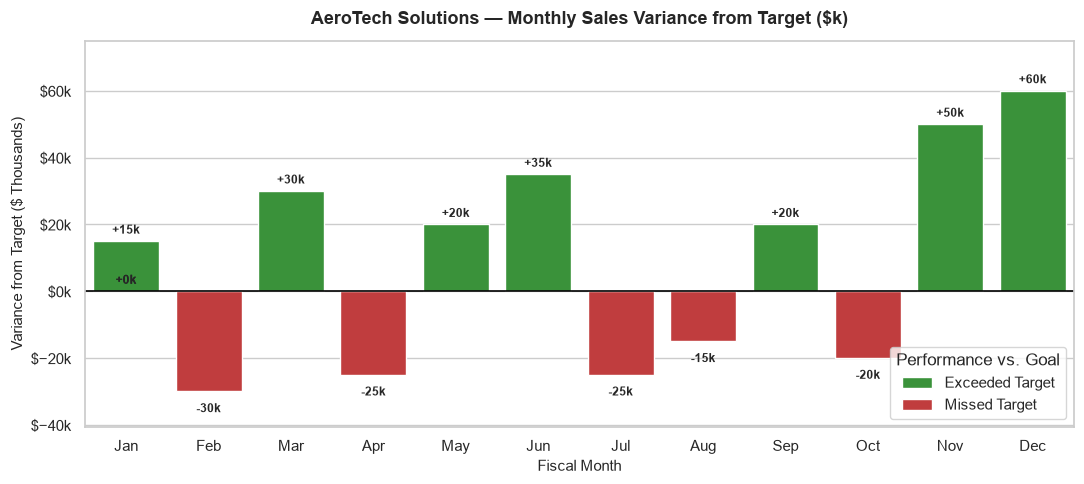

In [6]:
# Create diverging variance bar chart in Seaborn
plt.figure(figsize=(11, 5))

# Palette: Green for Exceeded, Red for Missed
palette_colors = {"Exceeded Target": "#2ca02c", "Missed Target": "#d62728"}

ax = sns.barplot(
    data=df,
    x="month",
    y="variance",
    hue="status",
    palette=palette_colors,
    dodge=False
)

# Prominent baseline at zero deviation
plt.axhline(0, color="black", linewidth=1.2)

plt.title("AeroTech Solutions — Monthly Sales Variance from Target ($k)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Fiscal Month", fontsize=11)
plt.ylabel("Variance from Target ($ Thousands)", fontsize=11)
plt.gca().yaxis.set_major_formatter('${x:,.0f}k')
plt.legend(title="Performance vs. Goal", loc="lower right")

# Add direct data labels above/below bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        va_align = 'bottom' if height >= 0 else 'top'
        y_pos = height + (1.5 if height >= 0 else -3.5)
        ax.annotate(f"{height:+.0f}k",
                    (p.get_x() + p.get_width() / 2., y_pos),
                    ha='center', va=va_align, fontsize=8.5, fontweight="bold")

plt.ylim(df["variance"].min() * 1.35, df["variance"].max() * 1.25)
plt.tight_layout()
plt.show()


## 7. Plotly Express Visualizations (Actual vs. Target & Variance)

With Plotly Express, we build:
1. A **Grouped Bar Chart** showing Actual Sales directly alongside Budget Target for every month.
2. An interactive **Diverging Variance Chart** with tooltips displaying exact percentage deviations.


In [7]:
# Reshape DataFrame for grouped side-by-side visualization
df_melted = df.melt(
    id_vars=["month"],
    value_vars=["sales_target", "actual_sales"],
    var_name="metric",
    value_name="sales"
)
df_melted["metric"] = df_melted["metric"].map({"sales_target": "Budget Target", "actual_sales": "Actual Sales"})

# Visualization 1: Grouped Bar Chart (Actual vs. Target)
fig_grouped = px.bar(
    df_melted,
    x="month",
    y="sales",
    color="metric",
    barmode="group",
    title="<b>Monthly Performance: Actual Sales vs. Budget Target ($k)</b>",
    labels={"sales": "Sales ($k)", "month": "Month", "metric": "Legend"},
    color_discrete_map={"Budget Target": "#7f7f7f", "Actual Sales": "#1f77b4"}
)

fig_grouped.update_layout(
    yaxis_tickprefix="$",
    yaxis_ticksuffix="k",
    template="plotly_white",
    legend_title=""
)
fig_grouped.show()


In [8]:
# Visualization 2: Interactive Diverging Variance Chart
fig_var = px.bar(
    df,
    x="month",
    y="variance",
    color="status",
    color_discrete_map={"Exceeded Target": "#2ca02c", "Missed Target": "#d62728"},
    hover_data={"variance": ":+,.0f", "variance_pct": ":+.1f%"},
    title="<b>Interactive Target Deviation ($ Thousands and % Variance)</b>",
    labels={"variance": "Variance ($k)", "month": "Month", "status": "Goal Status"}
)

fig_var.add_hline(y=0, line_color="black", line_width=1.5)
fig_var.update_layout(
    yaxis_tickprefix="$",
    yaxis_ticksuffix="k",
    template="plotly_white",
    showlegend=False
)
fig_var.show()


## 8. Interpretation

Examining the variance visuals reveals clear operational insights:

1. **Overall Year Performance (Net Surplus):**
   - In 7 out of 12 months, actual sales **exceeded targets** (positive variance).
   - In 5 months, sales **missed targets** (negative variance).
   - Overall net variance for the year was strongly positive: total actual sales ($6,585k) exceeded total budgeted targets ($6,470k) by **+$115,000 (+1.8%)**.

2. **The Standout Surge Months:**
   - **December** delivered the largest absolute dollar surplus (**+$60,000 / +8.3%**), driven by year-end contract closings.
   - **November** was also exceptionally strong (**+$50,000 / +7.8%**), followed by **June** (**+$35,000 / +6.3%**).

3. **The Deficit Months:**
   - **February** was the first shortfall month (-$30,000 / -6.8%).
   - **April** represented the largest percentage miss (**-$25,000 / -5.0%**).
   - **July and August** (mid-summer slump) recorded back-to-back target misses (-$25k and -$15k).


## 9. Key Insights & Recommended Business Actions

### What Happened?
- AeroTech met and exceeded its annual budget by 1.8%, but experienced predictable mid-quarter and summer dips in Q1 and Q3.

### Actionable Business Recommendations:
1. **Adjust Mid-Summer Targets for Next Year:**
   - Budget targets in July ($540k) and August ($520k) failed to account for European client holiday shutdowns. Lower summer targets by 5% and reallocate that quota into Q4 where buying intent is strongest.
2. **Investigate April Pipeline Drop:**
   - April was a significant shortfall following a stellar March. Sales reps likely pulled Q2 deals forward into March to hit Q1 commission bonuses, leaving April's pipeline starved. Implement commission incentives that reward quarterly pacing.
3. **Formalize Q4 Surge Playbooks:**
   - With November and December delivering over $110,000 in net surplus over quota, codify the year-end closing strategies used by top reps into standard onboarding playbooks.

---

### Common Analytical Mistake to Avoid:
> **Mistake: Evaluating Raw Actuals Without Benchmark Targets**  
> Reporting that *"December was our best month with $780k in sales"* is descriptive, but analytically shallow. What if December's target was $900k? That would mean December was actually a disastrous -$120k failure! Always compare operational actuals against a pre-established baseline (target, previous year, or forecast) to understand whether performance was truly favorable or unfavorable.


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Based on the deviation charts:
1. Which month had the largest positive dollar variance, and what was its dollar value?
2. Which month experienced the largest negative dollar variance?
3. How many total months in the year exceeded their target?


### Exercise 2: Modify Chart Settings (Percentage Variance Chart)
Dollar variance can sometimes obscure small percentage misses on large numbers.
In the code cell below:
- Create a Seaborn bar chart displaying **`variance_pct`** (%) instead of dollar variance.
- Add horizontal dashed threshold lines at **`+5%`** (green) and **`-5%`** (red) to visualize acceptable tolerance bands.
- Set an informative title: *"AeroTech Solutions — Monthly Percentage Variance vs. Target (%)"*.


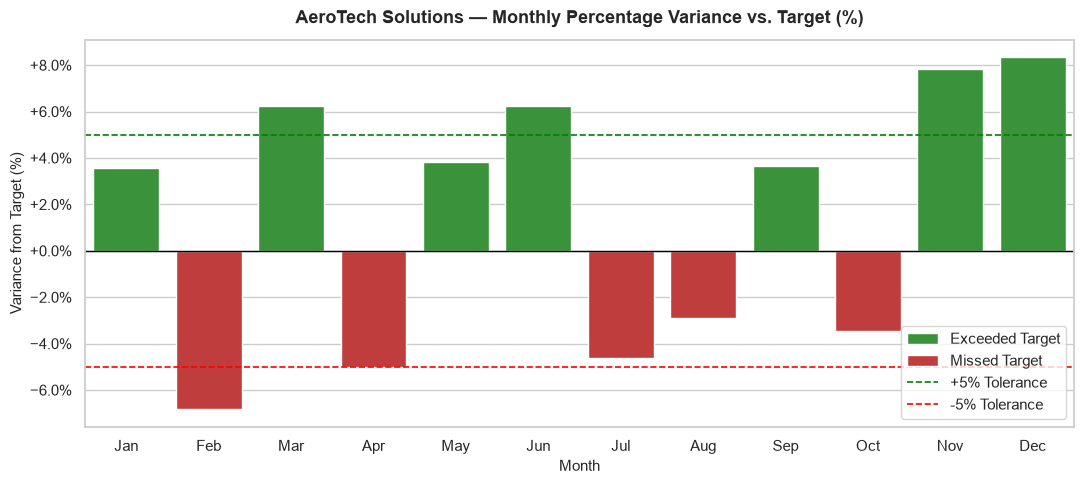

In [9]:
# Exercise 2: Student Code
plt.figure(figsize=(11, 5))

# Plot percentage variance
sns.barplot(
    data=df,
    x="month",
    y="variance_pct",
    hue="status",
    palette={"Exceeded Target": "#2ca02c", "Missed Target": "#d62728"},
    dodge=False
)

# Reference baseline and +/- 5% tolerance bands
plt.axhline(0, color="black", linewidth=1)
plt.axhline(5, color="green", linestyle="--", linewidth=1.2, label="+5% Tolerance")
plt.axhline(-5, color="red", linestyle="--", linewidth=1.2, label="-5% Tolerance")

plt.title("AeroTech Solutions — Monthly Percentage Variance vs. Target (%)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Variance from Target (%)", fontsize=11)
plt.gca().yaxis.set_major_formatter('{x:+.1f}%')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Exercise 3: Answer a Business Question (Quarterly Rollup Audit)
In corporate governance, bonuses are typically awarded based on **quarterly target attainment**.
Add a **`quarter`** column (`"Q1"` for Jan-Mar, `"Q2"` for Apr-Jun, `"Q3"` for Jul-Sep, `"Q4"` for Oct-Dec) and calculate the net dollar variance for each of the four quarters.
Did every quarter achieve net positive performance?


In [10]:
# Exercise 3: Student Code
quarter_map = {
    "Jan": "Q1", "Feb": "Q1", "Mar": "Q1",
    "Apr": "Q2", "May": "Q2", "Jun": "Q2",
    "Jul": "Q3", "Aug": "Q3", "Sep": "Q3",
    "Oct": "Q4", "Nov": "Q4", "Dec": "Q4"
}
df["quarter"] = df["month"].map(quarter_map)

# Group by quarter and sum targets and actuals
q_summary = df.groupby("quarter", as_index=False)[["sales_target", "actual_sales", "variance"]].sum()
q_summary["q_variance_pct"] = (q_summary["variance"] / q_summary["sales_target"]) * 100

print("Quarterly Performance Attainment Scorecard:")
print("-" * 65)
for _, row in q_summary.iterrows():
    result = "BEAT TARGET" if row['variance'] >= 0 else "MISSED TARGET"
    print(f"{row['quarter']} | Target: ${row['sales_target']:>5,.0f}k | Actual: ${row['actual_sales']:>5,.0f}k | Net Var: {row['variance']:>+4,.0f}k ({row['q_variance_pct']:>+4.1f}%) | {result}")


Quarterly Performance Attainment Scorecard:
-----------------------------------------------------------------
Q1 | Target: $1,340k | Actual: $1,355k | Net Var:  +15k (+1.1%) | BEAT TARGET
Q2 | Target: $1,580k | Actual: $1,610k | Net Var:  +30k (+1.9%) | BEAT TARGET
Q3 | Target: $1,610k | Actual: $1,590k | Net Var:  -20k (-1.2%) | MISSED TARGET
Q4 | Target: $1,940k | Actual: $2,030k | Net Var:  +90k (+4.6%) | BEAT TARGET


## 11. Challenge Activity

**Target Achievement Ratio & Cumulative Trajectory:**  
Executives love tracking **Target Achievement Rate (%)**:
$$\text{Achievement Rate} = \left( \frac{\text{Actual Sales}}{\text{Sales Target}} \right) \times 100$$
1. Calculate the achievement rate column.
2. Build an interactive Plotly Express line chart showing monthly achievement rate, adding a horizontal reference line at **100% (Par)**.
3. Write two executive insights regarding company momentum entering the next fiscal year.


In [11]:
# Challenge Activity: Target Achievement Rate
df["achievement_rate"] = (df["actual_sales"] / df["sales_target"]) * 100

fig_achieve = px.line(
    df,
    x="month",
    y="achievement_rate",
    markers=True,
    title="<b>Monthly Target Achievement Rate (Goal = 100%)</b>",
    labels={"achievement_rate": "Target Achievement Rate (%)", "month": "Fiscal Month"}
)
fig_achieve.add_hline(y=100, line_dash="dash", line_color="black", annotation_text="100% Target Par")
fig_achieve.update_layout(yaxis_ticksuffix="%", template="plotly_white")
fig_achieve.show()

# Print summary
print(f"Annual Cumulative Achievement Rate: {(df['actual_sales'].sum() / df['sales_target'].sum()) * 100:.2f}%")


Annual Cumulative Achievement Rate: 101.78%


## 12. Key Takeaways

- **Context is Everything:** Absolute numbers are uninformative without targets, quotas, or benchmark baselines.
- **Diverging Visuals for Variance:** Diverging bar charts centered around a clear zero baseline make it effortless to distinguish wins (favorable) from losses (unfavorable).
- **Track Both Dollars and Percentages:** A $50k variance on a $100k project (+50%) has vastly different operational implications than a $50k variance on a $5M project (+1%).
- **Color Discipline:** Use intuitive visual metaphors (green for favorable/exceeded, red for unfavorable/missed) to communicate status instantly to executive audiences.
